(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

,missing_rate
TotalCharges,0.001562


Churn rate: 0.265


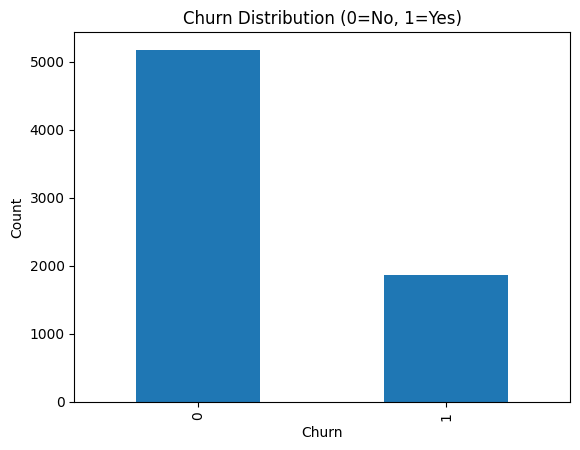

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection'] ... total: 16


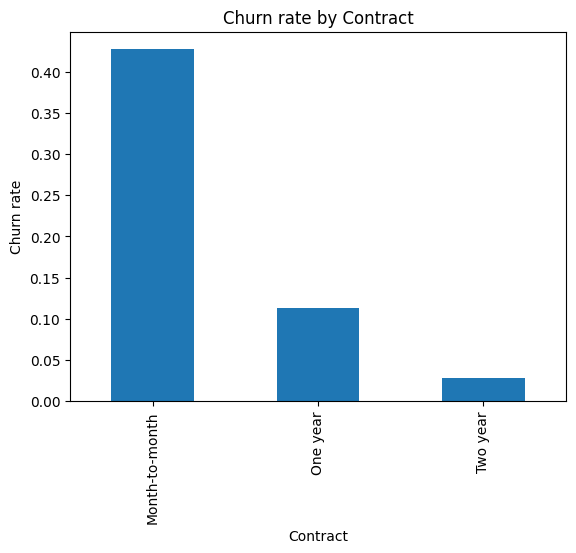

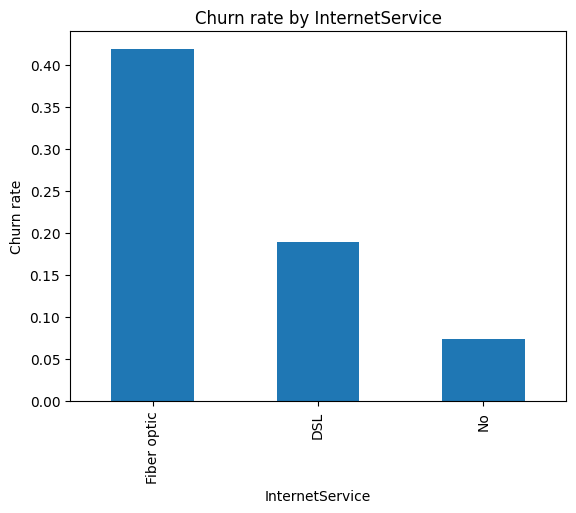

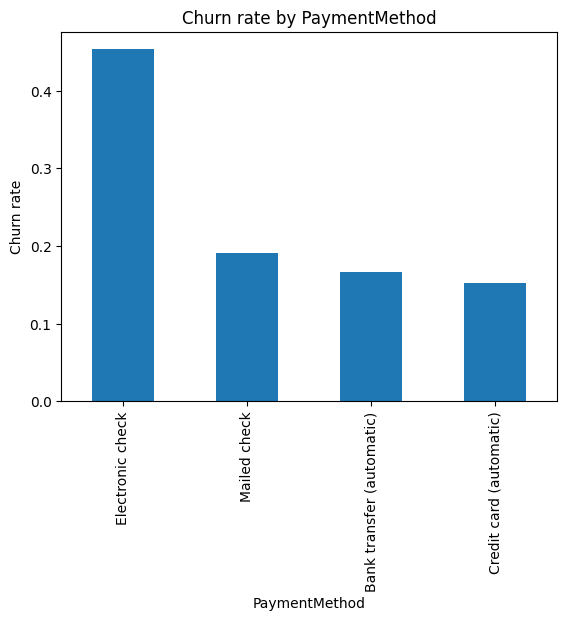

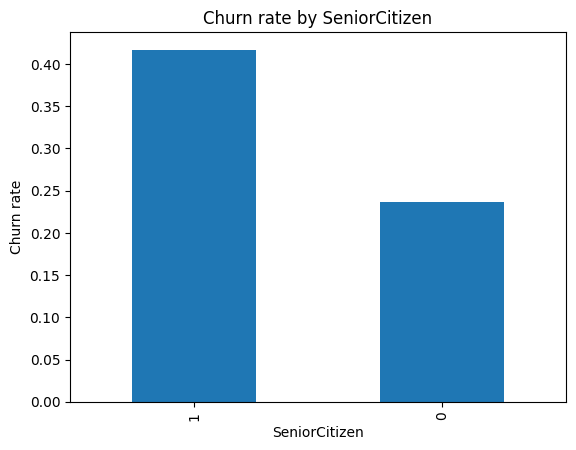

<Figure size 640x480 with 0 Axes>

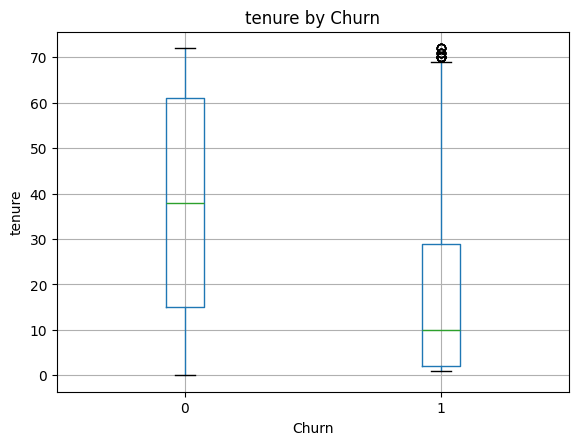

<Figure size 640x480 with 0 Axes>

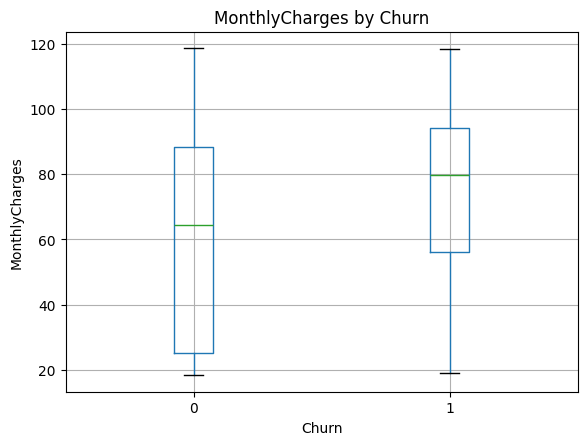

<Figure size 640x480 with 0 Axes>

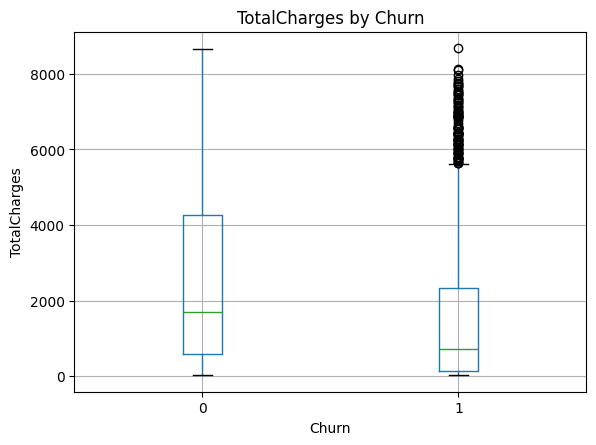

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

DATA_PATH = Path(r"C:\Users\User\OneDrive\Documents\OR PROJECTS\data\raw\telco_churn.csv")  # adjust if needed
df = pd.read_csv(DATA_PATH)

print(df.shape)
display(df.head())
display(df.dtypes)

# --- Standardize target ---
# Most Telco datasets have Churn as Yes/No
if df["Churn"].dtype == "object":
    df["Churn"] = (df["Churn"].str.strip().str.lower() == "yes").astype(int)

# --- Clean TotalCharges (often stored as string with blanks) ---
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# --- Basic missingness report ---
missing = df.isna().mean().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_rate"))

# --- Quick target rate ---
churn_rate = df["Churn"].mean()
print(f"Churn rate: {churn_rate:.3f}")

# --- Plot churn distribution ---
plt.figure()
df["Churn"].value_counts().sort_index().plot(kind="bar")
plt.title("Churn Distribution (0=No, 1=Yes)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# --- Identify numeric vs categorical ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols and c != "Churn"]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols[:10], "... total:", len(cat_cols))

# --- Simple driver checks: churn by key categories (top few) ---
def churn_by_category(col, topk=10):
    tmp = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    tmp = tmp.head(topk)
    plt.figure()
    tmp.plot(kind="bar")
    plt.title(f"Churn rate by {col}")
    plt.ylabel("Churn rate")
    plt.show()

for c in ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]:
    if c in df.columns:
        churn_by_category(c)

# --- Numeric relationship: churn vs tenure / MonthlyCharges ---
def boxplot_by_churn(col):
    plt.figure()
    df.boxplot(column=col, by="Churn")
    plt.title(f"{col} by Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

for c in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if c in df.columns:
        boxplot_by_churn(c)


In [3]:
print(df.columns.tolist())
print(df["Churn"].value_counts(dropna=False))

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Churn
0    5174
1    1869
Name: count, dtype: int64
